In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
#Definir las funciones de activación y entrenamiento
def step_function(x):
  return np.where(x>= 0,1,0)

#Función para hacer predicciones
def perceptron_predict(x, weights):
  y1 = step_function(np.dot(x, weights[0,1:]) + weights[0,0])
  y2 = step_function(np.dot(x, weights[1,1:]) + weights[1,0])

  return np.array([y1, y2])

In [54]:
def train(X,y,learning_rate = 0.1, epochs = 10):
  #Inicializar pesos
  weights = np.random.rand(2, X.shape[1]+1) * 0.01 #shape (2,3) 2 neuronas, 2 entradas + bias
  errors = []

  for _ in range(epochs):
    total_error = np.zeros(2)
    for xi, targets in zip(X,y):
      outputs = perceptron_predict(xi, weights)
      error = targets - outputs
      total_error += np.abs(error)

      for i in range(2):
        update = learning_rate * error[i]
        weights[i,1:] += update * xi
        weights[i,0] += update #Actualizar bias
    errors.append(total_error)
  return weights, np.array(errors)

Pesos entrenados para la neurona 1 - and: [-0.2949972   0.20345148  0.10778981]
Pesos entrenados para la neurona 2 - or: [-0.09546362  0.10369132  0.10281983]


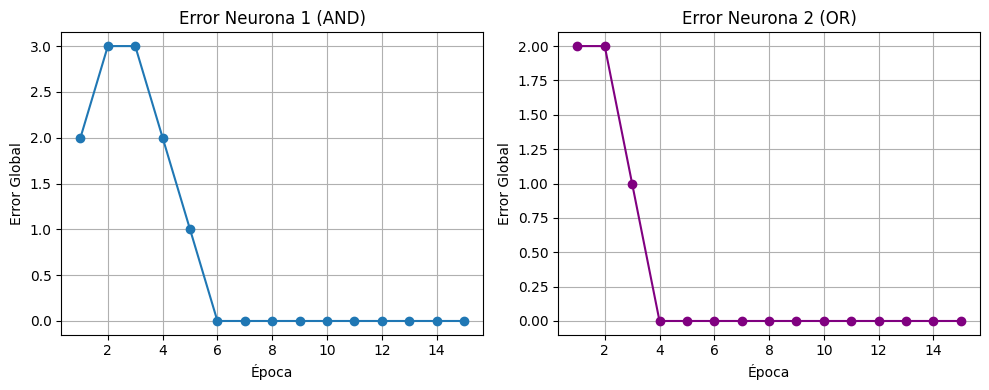

In [55]:
# Preparar los datos
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Salidas en una matriz
y = np.array([[0, 0],
              [0, 1],
              [0, 1],
              [1, 1]])

weights, errors = train(X, y, learning_rate=0.1, epochs=15)
print("Pesos entrenados para la neurona 1 - and:", weights[0])
print("Pesos entrenados para la neurona 2 - or:", weights[1])

# Graficar errores
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(errors) + 1), errors[:, 0], marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Neurona 1 (AND)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(errors) + 1), errors[:, 1], marker='o', color='purple')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Neurona 2 (OR)')
plt.grid(True)

plt.tight_layout()
plt.show()




In [56]:
print('COMPUERTA AND')
for xi in X:
    prediction = perceptron_predict(xi, weights)
    print(f"Entrada: {xi}, Salida predicha: {prediction[0]}")

print('\nCOMPUERTA OR')
for xi in X:
    prediction = perceptron_predict(xi, weights)
    print(f"Entrada: {xi}, Salida predicha: {prediction[1]}")


COMPUERTA AND
Entrada: [0 0], Salida predicha: 0
Entrada: [0 1], Salida predicha: 0
Entrada: [1 0], Salida predicha: 0
Entrada: [1 1], Salida predicha: 1

COMPUERTA OR
Entrada: [0 0], Salida predicha: 0
Entrada: [0 1], Salida predicha: 1
Entrada: [1 0], Salida predicha: 1
Entrada: [1 1], Salida predicha: 1


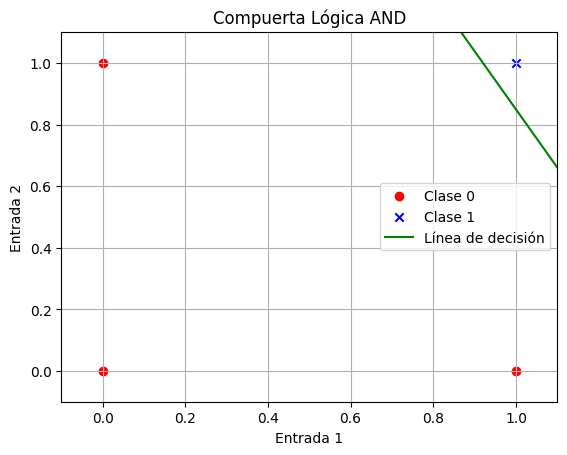

In [57]:
plt.figure(3)
# Graficar los puntos de datos para neurona 1
for i, xi in enumerate(X):
    if y[i,0] == 0:
        plt.scatter(xi[0], xi[1], color='red', marker='o', label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(xi[0], xi[1], color='blue', marker='x', label='Clase 1' if i == 3 else "")

# Definir la línea de decisión
x_values = np.array([-0.5, 1.5])
y_values = -(weights[0,1] * x_values + weights[0,0]) / weights[0,2]

# Graficar la línea de decisión

plt.plot(x_values, y_values, label='Línea de decisión', color='green')

# Configuraciones de la gráfica
plt.xlabel('Entrada 1')
plt.ylabel('Entrada 2')
plt.legend()
plt.title('Compuerta Lógica AND')
plt.grid(True)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# Mostrar la gráfica
plt.show()

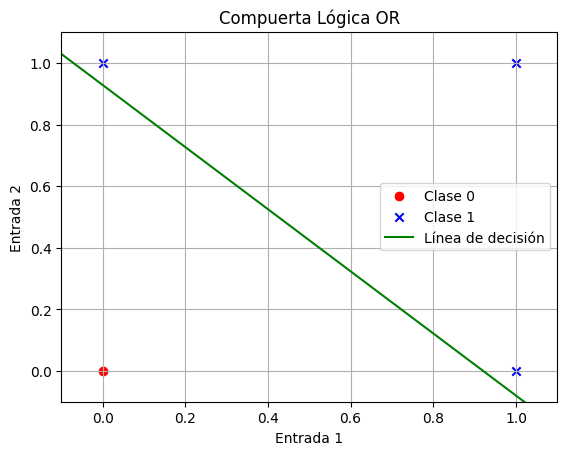

In [58]:
plt.figure(4)
# Graficar los puntos de datos para neurona 2
for i, xi in enumerate(X):
    if y[i,1] == 0:
        plt.scatter(xi[0], xi[1], color='red', marker='o', label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(xi[0], xi[1], color='blue', marker='x', label='Clase 1' if i == 3 else "")

x_values = np.array([-0.5, 1.5])
y_values2 = -(weights[1,1] * x_values + weights[1,0]) / weights[1,2]
#COMPUERTA OR

# Graficar la línea de decisión

plt.plot(x_values, y_values2, label='Línea de decisión', color='green')

# Configuraciones de la gráfica
plt.xlabel('Entrada 1')
plt.ylabel('Entrada 2')
plt.legend()
plt.title('Compuerta Lógica OR')
plt.grid(True)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# Mostrar la gráfica
plt.show()
